<a href="https://colab.research.google.com/github/DataAnalytics808/DASC-522-demo-repository/blob/main/demos/Week_09_3_Debugging_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##9E Debugging in Classification

This script is modified from https://colab.research.google.com/github/google/eng-edu/blob/master/ml/testing-debugging/testing-debugging-classification.ipynb?utm_source=ss-testing-debugging&utm_campaign=colab-external&utm_medium=referral&utm_content=testing-debugging-classification

#### Copyright 2018 Google LLC.

In [ ]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

### Case Study: Debugging in Classification

This Colab quickly demonstrates a few concepts related to debugging classification models. You will explore potential problems in implementing these tasks:

* Calculating loss for classification problems.
* Optimizing your model
* Applying regularization.
* Following best practices in development and debugging.

Please **make a copy** of this Colab before running it. Click on *File*, and then click on *Save a copy in Drive*.

### Load MNIST Data

MNIST is a dataset of images of the numbers 0 to 9. The problem is to classify the images as numbers. Setup libraries and load the MNIST dataset. Display the first few rows to verify that the data loaded. You'll explore the data format after the data loads.

In [ ]:
# Reset environment for a new run
# % reset -f

# Load Libraries
from os.path import join # for joining file pathnames
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import unittest
import sys

# Set Pandas display options
pd.options.display.max_rows = 10
pd.options.display.float_format = '{:.1f}'.format

# Load data
mnistDf_backup = pd.read_csv(
  "https://download.mlcc.google.com/mledu-datasets/mnist_train_small.csv",
  sep=",",
  header=None)
# Shuffle data
mnistDf_backup.sample(frac=1).reset_index(drop=True)
# Use the first 5000 examples for faster prototyping
mnistDf = mnistDf_backup[0:5000]

mnistDf.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,...,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,67,67,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,131,252,252,66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,159,250,232,30,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,222,252,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,147,252,183,5,0,0,0,0,0,0,0,20,89,89,73,0,0,...,0,0,0,249,252,244,126,98,143,252,252,237,240,253,252,243,174,17,0,0,0,0,0,0,0,0,0,0,0,0,0,119,239,252,252,252,252,252,252,252,252,228,179,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,46,66,66,66,66,66,66,66,66,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,59,50,0,23,0,0,32,134,180,254,206,8,0,0,0,0,0,0,0,0,0,0,0,0,4,96,216,233,254,248,215,231,215,215,236,254,250,181,27,0,0,0,0,0,0,0,0,0,0,0,0,0,108,254,254,247,175,175,175,176,175,175,205,175,60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,47,254,245,85,0,0,0,0,0,0,8,0,0,0,0,0,0,...,0,0,0,0,0,31,188,45,0,0,0,0,0,0,0,99,249,254,121,0,0,0,0,0,0,0,0,0,0,0,0,0,0,139,245,45,0,0,0,0,0,0,140,254,254,133,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,242,169,0,0,0,0,4,58,216,248,254,167,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,230,196,79,49,79,79,181,254,254,247,108,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,44,213,254,247,254,254,254,254,192,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,133,156,193,155,140,58,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

### Understanding the Data Format

Each row represents one labeled example. Column 0 represents the label that a human rater has assigned for one handwritten digit. For example, if Column 0 contains '5', then a human rater interpreted the handwritten character as the digit '5'.  The ten digits 0-9 are each represented, with a unique class label for each possible digit. Thus, this is a multi-class classification problem with 10 classes.

![img](https://wizardforcel.gitbooks.io/tensorflow-101-sjchoi86/content/basic_mnist_files/basic_mnist_5_2.png)

Columns 1 through 784 contain the feature values, one per pixel for the 28×28=784 pixel values. The pixel values are on a gray scale in which 0 represents white, 255 represents black, and values between 0 and 255 represent shades of gray.

### Do you have Imbalanced Classes?

As we read in the course, imbalanced classes make classification harder. Let's look at the distribution of classes. Do you have imbalanced classes?

([<matplotlib.axis.XTick at 0x7bf8218c2ea0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

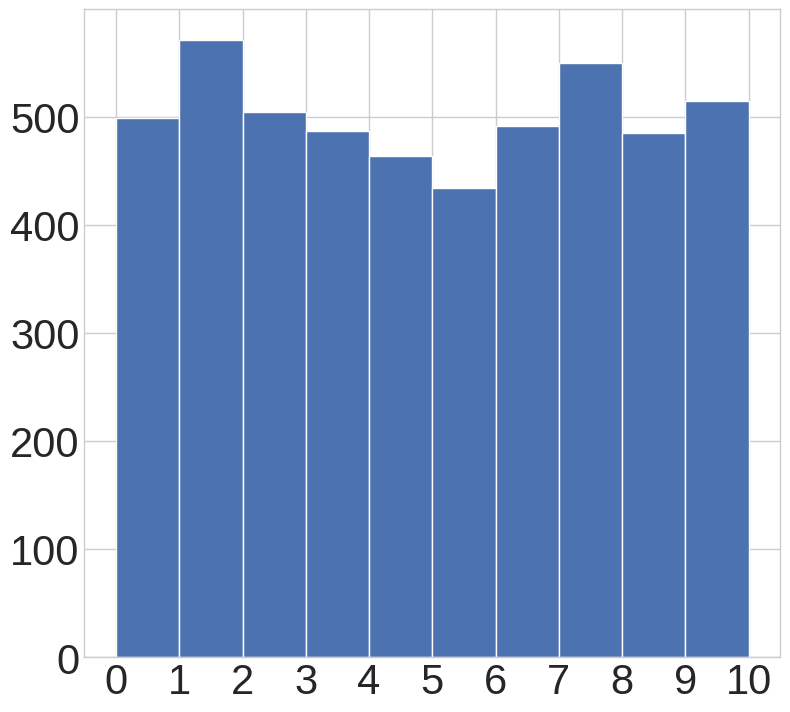

In [ ]:
# Calculate the number of classes
numClasses = mnistDf.iloc[:,0].unique().shape[0]
# Plot histogram of class distribution
plt.hist(mnistDf.iloc[:,0], bins=range(numClasses+1))
plt.xticks(range(numClasses+1))

The preceding graph shows that the 10 classes are roughly equally represented.

### Shuffle and Split Dataset

As part of [Data Debugging](https://developers.google.com/machine-learning/testing-debugging/common/data-errors) best practices, ensure your splits are statistically equivalent by shuffling your data to remove any pre-existing order.

In [ ]:
# Shuffle data
mnistDf = mnistDf.sample(frac=1).reset_index(drop=True)

# Split dataset into data and labels
mnistData = mnistDf.iloc[:,1:-1].copy(deep=True)
mnistLabels = mnistDf.iloc[:,0].copy(deep=True)

### Process Data

Scale the data values to `[0,1]` since the values are bounded to `[0,255]` and do not contain outliers. Then check that the scaled data values are as expected by generating summary statistics using the `DataFrame.describe()` function.

Run the following cell to scale data and generate statistics. This cell takes a few minutes to run.

In [ ]:
mnistData = mnistData.astype(float)

col_min = mnistData.min()
col_range = mnistData.max() - col_min
col_range = col_range.replace(0, 1)

mnistData = (mnistData - col_min) / col_range

mnistData.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,...,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,...,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,

Oh no! Some of your features are all `NaN`. What do you think the cause is? Hint: While NaNs have many causes, in this case, the NaN values are caused by the properties of your data. Use the next code cell to explore your data. Then check the next cell for the solution. Try to find the solution yourself. Debugging `NaN`s and exploring your data are important skills.

In [ ]:
# First reload your data
mnistData = mnistDf.iloc[:,1:-1].copy(deep=True)

Start exploring your data by generating a high-level summary using `Dataframe.describe()`.

In [ ]:
mnistData.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,...,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,...,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,

Because some of the feature columns are all zeros, the scaling function divided by 0 (because `np.max` returns 0). The division by 0 resulted in NaN values. This result shows you how easily NaNs can arise in engineered data. The `describe` function will not detect every occurrence of NaN (or None). Instead,  use the command `DataFrame.isnull().any()`.

*Note*: Given the maximum value of the feature data is 255, you could simply divide the input by 255 instead of using min-max scaling, and avoid introducing NaNs. However, this example purposely uses min-max scaling to show how NaNs can appear in engineered data.

Now let's try scaling the data again.

In [ ]:
mnistData = mnistDf.iloc[:, 1:-1].copy(deep=True).astype(float)

mins = mnistData.min()
ranges = mnistData.max() - mins
ranges = ranges.replace(0, 1)

mnistData = (mnistData - mins) / ranges

Verify

In [ ]:
mnistData.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,...,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,...,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,

In [ ]:
mnistLabels.describe()

count   5000.0
mean       4.5
std        2.9
min        0.0
25%        2.0
50%        4.0
75%        7.0
max        9.0
Name: 0, dtype: float64

You should follow best practice and prevent this bug from recurring by writing a unit test to check for not having `NaN` values in your engineered data.

### Remove All-Zero Features?

You might think that getting NaNs and discovering that some features were all-zero is good luck because those features can be discarded. However, your training data and validation data might have different all-zero features. Since you should not use validation data to make modeling decisions, you cannot remove only those features that are all-zero in both. Furthermore, data in the future might have different characteristics. There are pros and cons in either case. This Colab keeps the features since reducing the feature set is not a concern.

### Establish Baseline

Following development best practices, you should establish a baseline. The simplest baseline is predicting the most common class. You saw that the most common class is 1. Let's check the accuracy when always predicting 1.

In [ ]:
np.sum(mnistLabels==1)*1.0/mnistLabels.shape[0]*100

np.float64(11.42)

Your baseline accuracy is about 11%. Should be easy to beat, right?

Create a classical ML model

In [ ]:
# This code chunk modified slightly from https://gurus.pyimagesearch.com/lesson-sample-k-nearest-neighbor-classification/

# import the necessary packages
from __future__ import print_function
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import datasets
from skimage import exposure
import numpy as np
import imutils
import cv2
import sklearn

from sklearn.model_selection import train_test_split

# load the MNIST digits dataset
mnist = datasets.load_digits()  # <--- this will use reduced MNIST dataset from sklearn

# take the MNIST data and construct the training and testing split, using 60% of the
# data for training and 40% for testing

(trainData, testData, trainLabels, testLabels) = train_test_split(np.array(mnist.data),
	mnist.target, test_size=0.40)  # random_state=42

# show the sizes of each data split
print("training data points: {}".format(len(trainLabels)))
# print("validation data points: {}".format(len(valLabels)))
print("testing data points: {}".format(len(testLabels)))

# initialize the values of k for our k-Nearest Neighbor classifier along with the
# list of accuracies for each value of k
kVals = range(1, 30, 2)
accuracies = []

# loop over various values of `k` for the k-Nearest Neighbor classifier
for k in range(1, 30, 2):
	# train the k-Nearest Neighbor classifier with the current value of `k`
	model = KNeighborsClassifier(n_neighbors=k)
	model.fit(trainData, trainLabels)

	# evaluate the model and update the accuracies list
	score = model.score(testData, testLabels)
	print("k=%d, accuracy=%.2f%%" % (k, score * 100))
	accuracies.append(score)

# find the value of k that has the largest accuracy
i = int(np.argmax(accuracies))
print("\nk=%d achieved highest accuracy of %.4f%% on validation data" % (kVals[i],
	accuracies[i] * 100))

# re-train our classifier using the best k value and predict the labels of the
# test data
model = KNeighborsClassifier(n_neighbors=kVals[i])
model.fit(trainData, trainLabels)
predictions = model.predict(testData)

# show a final classification report demonstrating the accuracy of the classifier
# for each of the digits
print("\nEVALUATION ON TESTING DATA")
print(classification_report(testLabels, predictions))


training data points: 1078
testing data points: 719
k=1, accuracy=98.89%
k=3, accuracy=98.33%
k=5, accuracy=98.47%
k=7, accuracy=98.05%
k=9, accuracy=97.77%
k=11, accuracy=97.22%
k=13, accuracy=97.22%
k=15, accuracy=96.66%
k=17, accuracy=96.66%
k=19, accuracy=96.24%
k=21, accuracy=95.97%
k=23, accuracy=95.83%
k=25, accuracy=95.83%
k=27, accuracy=95.83%
k=29, accuracy=95.83%

k=1 achieved highest accuracy of 98.8873% on validation data

EVALUATION ON TESTING DATA
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       0.97      0.99      0.98        77
           2       1.00      1.00      1.00        71
           3       1.00      0.99      0.99        77
           4       0.99      1.00      0.99        66
           5       0.98      0.98      0.98        64
           6       1.00      1.00      1.00        73
           7       1.00      0.98      0.99        64
           8       1.00      0.96      0.98   

### Train a Linear Model

Let's start nice and easy with a linear model. All we need is an accuracy > 11%.

First, let's define a function to plot our loss and accuracy curves. The function will also print the final loss and accuracy. Instead of using `verbose=1`, you can call the function.

In [ ]:
def showClassificationResults(trainHistory):
  """Function to:
   * Print final loss & accuracy.
   * Plot loss & accuracy curves.

  Args:
    trainHistory: object returned by model.fit
  """

  # Print final loss and accuracy
  print("Final training loss: " + str(trainHistory.history['loss'][-1]))
  print("Final validation loss: " + str(trainHistory.history['val_loss'][-1]))
  print("Final training accuracy: " + str(trainHistory.history['accuracy'][-1]))
  print("Final validation accuracy: " + str(trainHistory.history['val_accuracy'][-1]))

  # Plot loss and accuracy curves
  f = plt.figure(figsize=(10,4))
  axLoss = f.add_subplot(121)
  axAcc = f.add_subplot(122)
  axLoss.plot(trainHistory.history['loss'])
  axLoss.plot(trainHistory.history['val_loss'])
  axLoss.legend(['Training loss', 'Validation loss'], loc='best')
  axLoss.set_xlabel('Training epochs')
  axLoss.set_ylabel('Loss')
  axAcc.plot(trainHistory.history['accuracy'])
  axAcc.plot(trainHistory.history['val_accuracy'])
  axAcc.legend(['Training accuracy', 'Validation accuracy'], loc='best')
  axAcc.set_xlabel('Training epochs')
  axAcc.set_ylabel('Accuracy')

Now train a linear model with an output layer and a hidden layer.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training loss: 3.319072723388672
Final validation loss: 4.024559497833252
Final training accuracy: 0.14524999260902405
Final validation accuracy: 0.13899999856948853


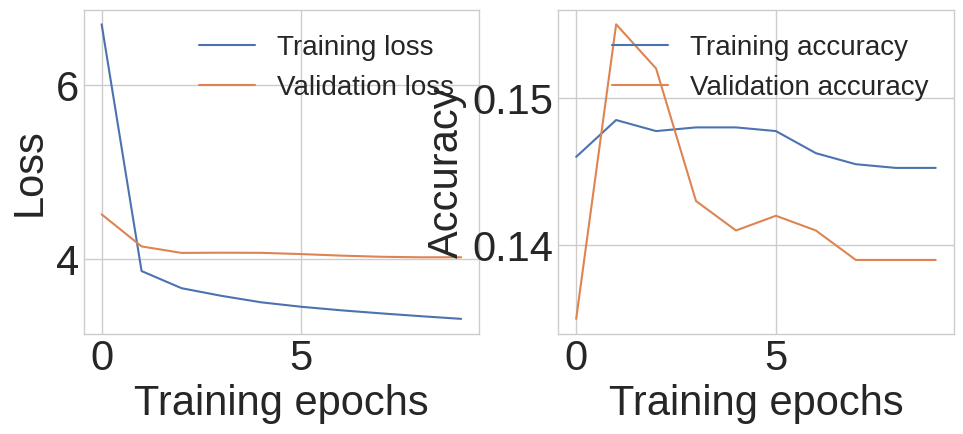

In [ ]:
model = None
# Define
model = keras.Sequential()
model.add(keras.layers.Dense(mnistData.shape[1],
                             activation='linear',
                             input_dim=mnistData.shape[1]))
model.add(keras.layers.Dense(1, activation='linear'))
# Compile
model.compile(optimizer="adam", loss='mse', metrics=['accuracy'])
# Train
trainHistory = model.fit(mnistData, mnistLabels, epochs=10, batch_size=100,
                         validation_split=0.2, verbose=0)
# Plot
showClassificationResults(trainHistory)

Wow, that accuracy is terrible! What could the cause be?

Hint: You followed the same procedure as for the previous regression problem. Do you need an adaptation for a classification problem? Experiment with the code above or skip to the solution below.

### Solution

In regression, the last layer uses a linear activation function. In classification, the last layer cannot use a linear transform. Instead, one option is a softmax transform. Furthermore, in regression, the loss is calculated using MSE while in classification, loss is calculated using crossentropy. Before running your model, if you wrote a test to validate the output values, your test would detect the anomalous output. You'll look at such a test later. Move onto the next section to fix the loss calculation.

### Fixing Loss Calculation

Since your labels are integers instead of one-hot encodings, use `sparse_categorical_crossentropy` instead of `categorical_crossentropy` so that you avoid converting the integers to one-hot encoding.

Retrain the model with the new loss calculation by running the following cell. Look through the code to note the changes. What do you think of the result?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training loss: 0.1649104505777359
Final validation loss: 0.4964163899421692
Final training accuracy: 0.9551110863685608
Final validation accuracy: 0.8659999966621399


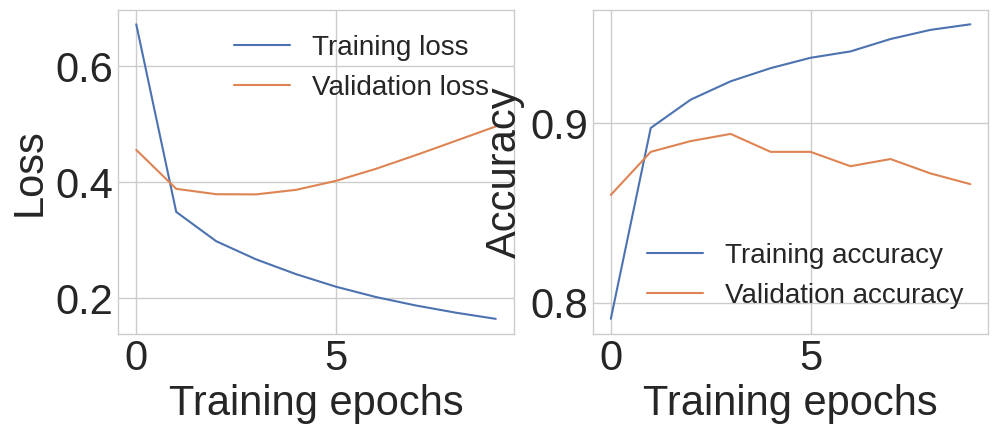

In [ ]:
model = None
# Define
model = keras.Sequential()
model.add(keras.layers.Dense(mnistData.shape[1], activation='linear',
                             input_dim = mnistData.shape[1]))
model.add(keras.layers.Dense(10, activation='softmax'))
# Compile
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Train
trainHistory = model.fit(mnistData, mnistLabels, epochs=10, batch_size=100,
                         validation_split=0.1, verbose=0)
# Plot
showClassificationResults(trainHistory)

Your loss curves are much better. Your accuracy has improved too. You're on the right track.

### Train a Nonlinear Model

Switch to a nonlinear model by modifying the code below to use relu activation functions instead of linear activation functions. Run the code. What do you observe?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training loss: 0.0046501485630869865
Final validation loss: 0.22642569243907928
Final training accuracy: 1.0
Final validation accuracy: 0.9359999895095825


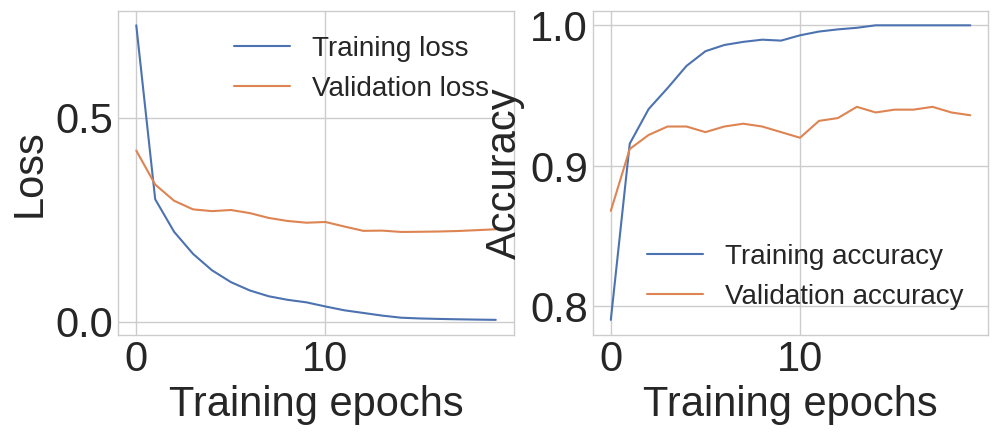

In [ ]:
model = None
# Define
model = keras.Sequential()
model.add(keras.layers.Dense(mnistData.shape[1], activation='relu', # use 'relu'
                             input_dim=mnistData.shape[1]))
model.add(keras.layers.Dense(10, activation='sigmoid'))
# Compile
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Train
trainHistory = model.fit(mnistData, mnistLabels, epochs=20, batch_size=100,
                        validation_split=0.1, verbose=0)
# Plot
showClassificationResults(trainHistory)

The quality of the nonlinear model is significantly better than of the linear model. Progress! Move onto the next section.

### Adding a Second Layer

Increasing the model's capacity significantly improved your results. Perhaps you can continue this strategy by adding a second relu layer. Run the following code cell to train the model with another relu layer.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training loss: 0.009111326187849045
Final validation loss: 0.23064565658569336
Final training accuracy: 0.9975555539131165
Final validation accuracy: 0.949999988079071


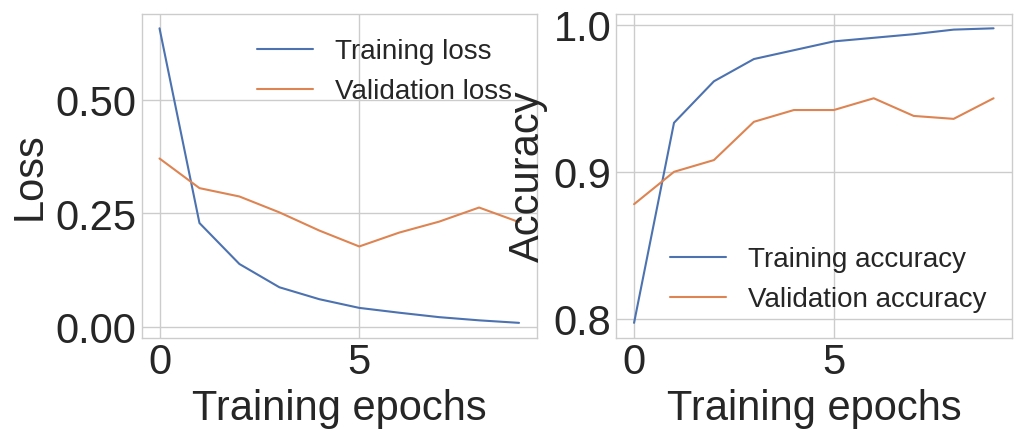

In [ ]:
model = None
# Define
model = keras.Sequential()
model.add(keras.layers.Dense(mnistData.shape[1], activation='relu',
                             input_dim = mnistData.shape[1]))
model.add(keras.layers.Dense(mnistData.shape[1], activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))
# Compile
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Train
trainHistory = model.fit(mnistData, mnistLabels, epochs=10, batch_size=100,
                        validation_split=0.1, verbose=0)
# Plot
showClassificationResults(trainHistory)

Guess what. Your previous model had training and validation accuracies of 100% and 95%. You can't do much better than that! So your new accuracy is about the same. How high can you push your accuracy? With this configuration the highest training and validation accuracies appear to be 100% and 96% respectively. Since the neural net returns similar accuracy with 1 or 2 layers, let's use the simpler model with 1 layer.

Does your model begin to overfit the training data if you train for long enough? (Your model starts overfitting training data at the point when your validation loss starts increasing.)

### Check for Training/Validation Data Skew

Our validation accuracy is a little worse than our training accuracy. While this result is always expected, you should check for typical errors. The commonest cause is having different distributions of data and labels in training and validation. Confirm that the distribution of classes in training and validation data is similar.

([<matplotlib.axis.XTick at 0x7bf80b48b4d0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

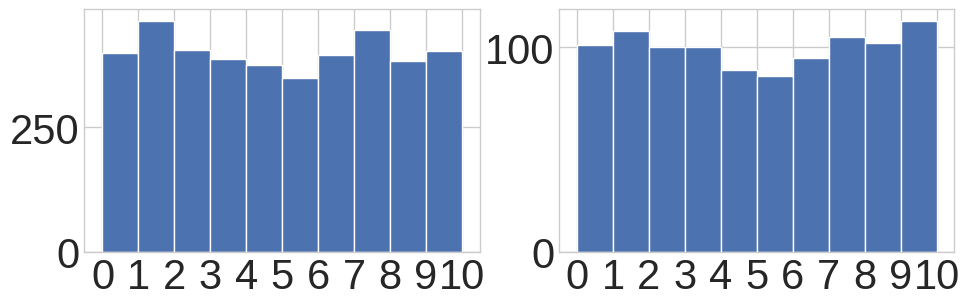

In [ ]:

f = plt.figure(figsize=(10,3))
ax = f.add_subplot(1,2,1)

split_index = int(len(mnistLabels)*8/10)
plt.hist(mnistLabels[0:split_index], bins=range(numClasses+1))
plt.xticks(range(numClasses+1))
ax2 = f.add_subplot(1,2,2,)
plt.hist(mnistLabels[split_index:-1], bins=range(numClasses+1))
plt.xticks(range(numClasses+1))

### Apply Dropout Regularization

Dropout regularization is a common regularization method that removes a random selection of a fixed number of units in a network layer for a single gradient step. Typically, dropout will improve generalization at a dropout rate of between 10% and 50% of neurons.

Try to reduce the divergence between training and validation loss by using dropout regularization with values between 0.1 and 0.5. Dropout does not improve the results in this case. However, at a dropout of 0.5, the difference in loss decreases, though both training and validation loss decrease in absolute terms.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training loss: 0.014036393724381924
Final validation loss: 0.222720667719841
Final training accuracy: 0.9991111159324646
Final validation accuracy: 0.9419999718666077


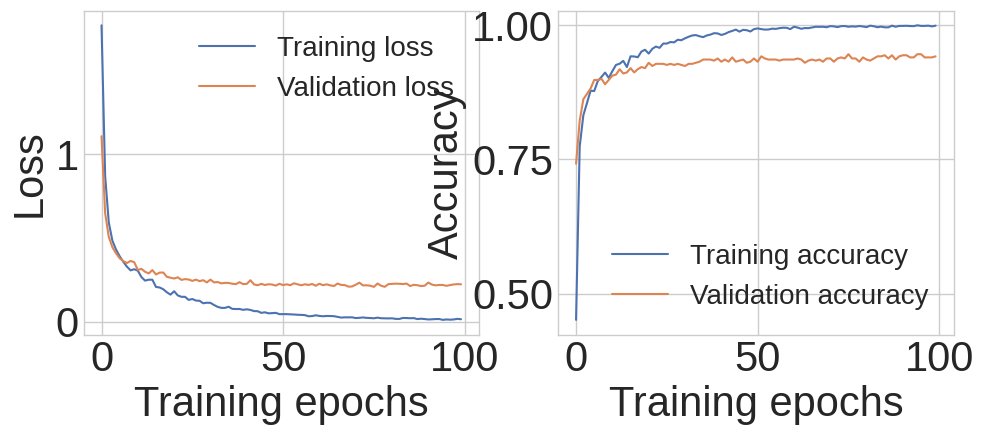

In [ ]:
from keras import regularizers
model = None
# Define lambda
dropoutLambda = 0.5 #@param
# Define model
model = keras.Sequential()
model.add(keras.layers.Dense(mnistData.shape[1],
                             input_dim=mnistData.shape[1],
                             activation='relu'))
model.add(keras.layers.Dropout(dropoutLambda,
                               noise_shape=(1, mnistData.shape[1])))
model.add(keras.layers.Dense(10, activation='softmax'))
# Compile
model.compile(optimizer = "adam",
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
# Train
trainHistory = model.fit(mnistData,
                        mnistLabels,
                        epochs=100,
                        batch_size=500,
                        validation_split=0.1,
                        verbose=0)
# Plot
showClassificationResults(trainHistory)

Sample results using dropout regularization after 30 epochs:

Lambda | Training Loss | Validation Loss
------- | ------------------------------------------------------
0.1 | 0.99 | 0.95
0.2 | 0.99 | 0.95
0.3 | 0.99 | 0.95
0.5 | 0.97 | 0.94

### Check Accuracy for Data Slices

For classification problems, you should always check the metrics by class to ensure your model predicts well across all classes. Check accuracy on the 10 classes by running the next cell by using the function `sklearn.metrics.classification_report` from the scikit-learn library. In the output, the rows with indices 0 to 9 correspond to the classes for the labels 0 to 9. The columns "Precision", "Recall", and "[F1-Score](https://en.wikipedia.org/wiki/F1_score)" correspond to the respective classification metrics for each class. "Support" is the number of examples for the class in question. For example, for the label "4", when predicting on 464 examples labelled "4", the model has a precision of 0.98, a recall of 0.97, and a F1 score of 0.98.

The classification metrics are very uniform across all classes, which is perfect. In your classification problem, in case any metric is lower for a class, then you should investigate why the model has lower-quality predictions for that class.

In [ ]:
from sklearn.metrics import classification_report
mnistPred = model.predict(x = mnistData)
mnistPred = np.round(mnistPred)
mnistPred = np.argmax(mnistPred, axis = 1) # condense one-hot-encoded output to a single number
print(classification_report(mnistLabels, mnistPred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       499
           1       1.00      1.00      1.00       571
           2       0.98      1.00      0.99       504
           3       0.99      0.99      0.99       487
           4       0.99      1.00      0.99       464
           5       1.00      1.00      1.00       434
           6       1.00      1.00      1.00       491
           7       0.99      0.99      0.99       550
           8       1.00      0.98      0.99       485
           9       1.00      0.99      1.00       515

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



In [ ]:
mnistLabels, mnistPred

(0       4
 1       0
 2       3
 3       9
 4       1
        ..
 4995    3
 4996    9
 4997    3
 4998    1
 4999    6
 Name: 0, Length: 5000, dtype: int64,
 array([4, 0, 3, ..., 3, 1, 6]))

### Conclusion

The Colab demonstrated the following principles:

* Calculate loss correctly for your problem.
* Verify and unit test your engineered data.
* Find the right model capacity through experimentation.
* Find the best regularization through experimentation.
* Check quality on data slices.